## How the label horizon changes the target

Both label files cover the exact same 59,270,407 pixels: every pixel NLCD called
wetland in Florida in 2019. The only thing that differs is how long we wait
before reading the pixel again. `wetland_sample_labels_2019_2020.parquet` reads
it one year later, `wetland_sample_labels_2019_2024.parquet` five years later.

Provenance: Annual NLCD LndCov CU C1V2, built by `build_labels.py`.

Rates below are always the share of that same 59.3 million pixel denominator, so
the two horizons are directly comparable.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

FIG_DIR = Path("results/figures/label_horizon")
FIG_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = {
    "2019 to 2020": "data/wetland_sample_labels_2019_2020.parquet",
    "2019 to 2024": "data/wetland_sample_labels_2019_2024.parquet",
}

CLASS_NAMES = {
    0: "Remained wetland",
    1: "Converted to developed",
    2: "Converted to other, not developed",
}

# Color carries the destination class and nothing else; the horizon is always
# carried by position or marker shape. Checked with an OKLab distance under
# simulated protanopia, deuteranopia, and tritanopia: worst pair is developed
# versus other at deltaE 9.9, above the 8 threshold. The green is only 2.8:1
# against white, under the 3:1 mark target, which is why every bar and dot below
# gets a direct label instead of leaning on the fill.
CLASS_COLORS = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a"}

INK, MUTED, GRID = "#1a1a1a", "#52514e", "#e2e2dd"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "axes.titlepad": 14,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": INK,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [2]:
counts = pd.DataFrame(
    {
        name: np.bincount(
            pq.read_table(path, columns=["label"])["label"].to_numpy(), minlength=3
        )[:3]
        for name, path in HORIZONS.items()
    },
    index=[0, 1, 2],
)

# Same pixels in both files, so one denominator. If this ever trips, the two
# horizons stopped being comparable and every rate below is meaningless.
n_sample = counts.sum()
assert n_sample.nunique() == 1, f"sample sizes differ: {n_sample.to_dict()}"
n_sample = int(n_sample.iloc[0])

rates = 100 * counts / n_sample

table = pd.concat(
    {"pixels": counts, "percent": rates.round(4)}, axis=1
).swaplevel(axis=1).sort_index(axis=1)
table.index = [CLASS_NAMES[i] for i in counts.index]
print(f"sample: {n_sample:,} Florida pixels classified wetland in 2019\n")
print(table.to_string())

sample: 59,270,407 Florida pixels classified wetland in 2019

                                  2019 to 2020           2019 to 2024          
                                       percent    pixels      percent    pixels
Remained wetland                       99.8269  59167814      99.3434  58881237
Converted to developed                  0.0508     30128       0.2799    165908
Converted to other, not developed       0.1223     72465       0.3767    223262


### The headline number

The thing that actually matters for modeling is the positive rate, so lead with
it. Waiting five years instead of one gives 5.5 times more positives to train
on. A bar chart of two numbers this close to zero is worse than just printing
them.


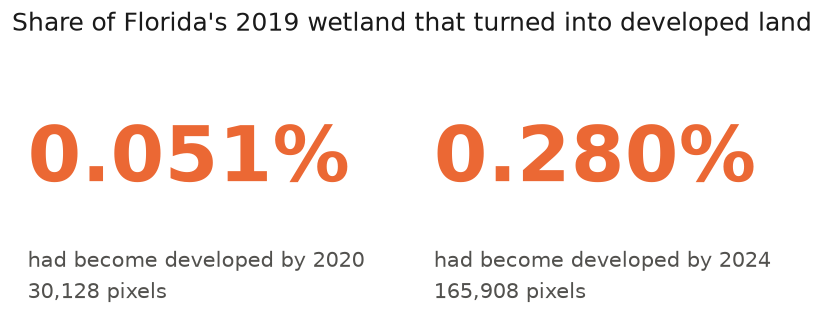

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 2.9))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

for i, horizon in enumerate(HORIZONS):
    x = 0.02 + 0.52 * i
    end_year = horizon.split()[-1]
    ax.text(x, 0.60, f"{rates.loc[1, horizon]:.3f}%", fontsize=46, fontweight="bold",
            color=CLASS_COLORS[1], ha="left", va="center")
    ax.text(x, 0.17, f"had become developed by {end_year}\n{counts.loc[1, horizon]:,} pixels",
            fontsize=12.5, color=MUTED, ha="left", va="center", linespacing=1.5)

ax.set_title("Share of Florida's 2019 wetland that turned into developed land", loc="left")
fig.savefig(FIG_DIR / "developed_conversion_rate_headline.png")
plt.show()

### Both destinations, both horizons

Dropping "remained wetland" here on purpose: at 99.8 percent it would flatten
both conversion bars into invisible slivers. This panel is only about where the
wetland that *did* change ended up. Note that "other" outruns "developed" at
both horizons, and that roughly half of it is open water, which is water level
rather than land conversion.


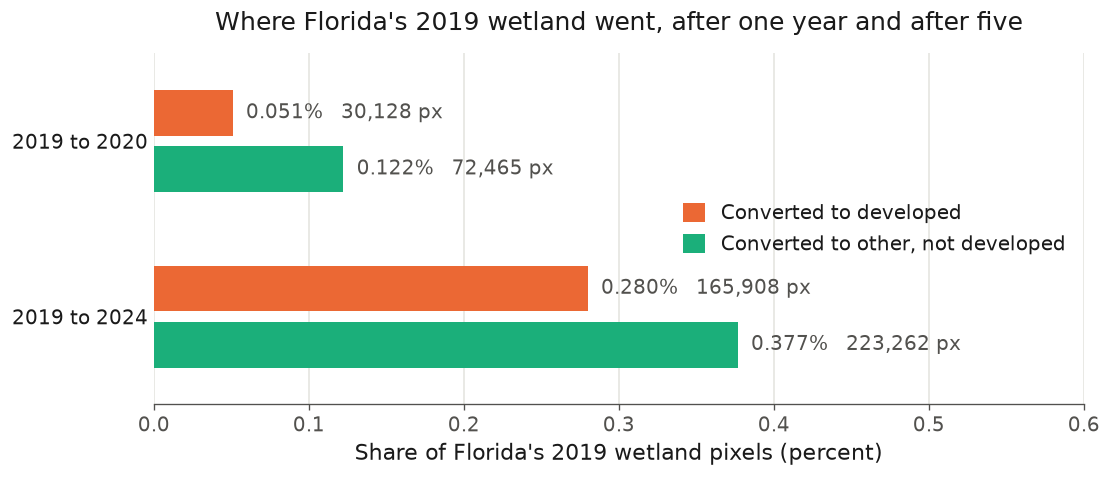

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.8))

horizons = list(HORIZONS)
y = np.arange(len(horizons))
bar_h = 0.26
offsets = {1: -0.16, 2: 0.16}  # leaves a clear gap between the paired bars

for cls, off in offsets.items():
    bars = ax.barh(y + off, rates.loc[cls, horizons], height=bar_h,
                   color=CLASS_COLORS[cls], label=CLASS_NAMES[cls], zorder=3)
    for bar, horizon in zip(bars, horizons):
        ax.annotate(f"{rates.loc[cls, horizon]:.3f}%   {counts.loc[cls, horizon]:,} px",
                    xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                    xytext=(8, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=12, color=MUTED)

ax.set_yticks(y, horizons)
ax.set_ylim(len(horizons) - 0.5, -0.5)
ax.set_xlim(0, 0.60)
ax.set_xlabel("Share of Florida's 2019 wetland pixels (percent)")
ax.set_title("Where Florida's 2019 wetland went, after one year and after five")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color=GRID, linewidth=0.9, zorder=0)
ax.set_axisbelow(True)
# parked in the dead band between the two horizon groups, the only place it
# does not run into a bar label
ax.legend(frameon=False, loc="center right", handlelength=1.1, handleheight=1.1)

fig.savefig(FIG_DIR / "conversion_rate_by_destination.png")
plt.show()

### The full composition, including the pixels that stayed put

This is the rare event problem drawn to scale. The x axis is log, which is the
only way to put 59 million and 30 thousand on one row and still see both. A dot
plot rather than bars, because a bar on a log axis encodes length from a
meaningless origin. Each line runs from the one year count to the five year
count, so its length is how much more of that class you catch by waiting.


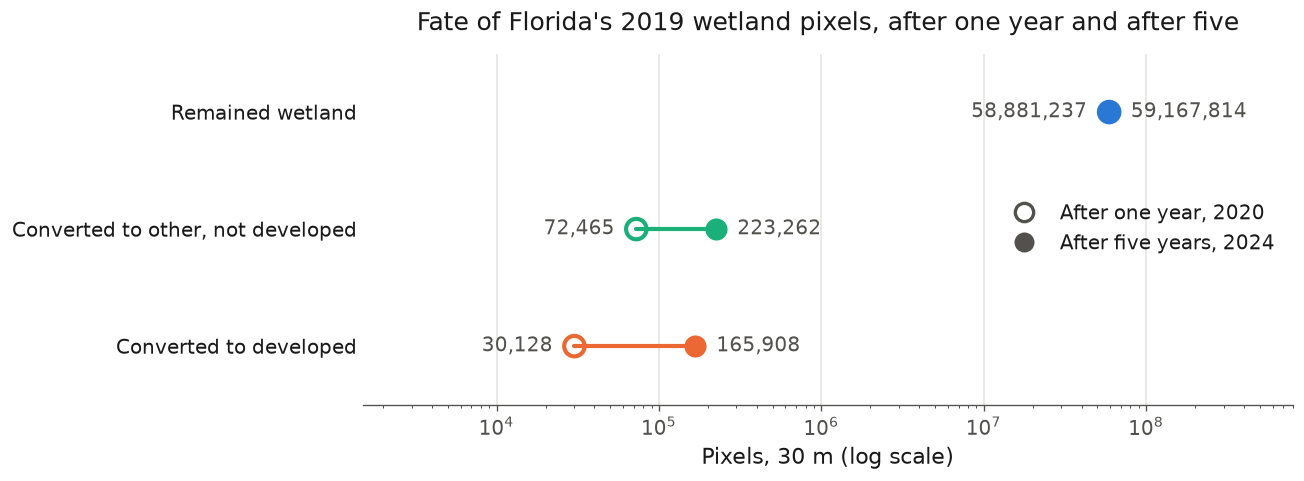

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.8))

order = [0, 2, 1]  # most common class at the top
for i, cls in enumerate(order):
    one_yr, five_yr = (counts.loc[cls, h] for h in horizons)
    lo, hi = sorted((one_yr, five_yr))
    ax.plot([one_yr, five_yr], [i, i], color=CLASS_COLORS[cls], lw=2.5, zorder=2,
            solid_capstyle="round")
    ax.scatter([five_yr], [i], s=150, color=CLASS_COLORS[cls], zorder=3)
    # hollow, not white filled: for remained wetland the two counts differ by
    # half a percent, so on a log axis they land on the same pixel and a white
    # fill would hide the five year marker entirely
    ax.scatter([one_yr], [i], s=150, facecolor="none", edgecolor=CLASS_COLORS[cls],
               lw=2.5, zorder=4)
    # smaller value labelled to the left, larger to the right, so the pair never
    # collides even where the two markers sit on top of each other
    ax.annotate(f"{lo:,}", xy=(lo, i), xytext=(-13, 0), textcoords="offset points",
                ha="right", va="center", fontsize=12, color=MUTED)
    ax.annotate(f"{hi:,}", xy=(hi, i), xytext=(13, 0), textcoords="offset points",
                ha="left", va="center", fontsize=12, color=MUTED)

ax.set_xscale("log")
ax.set_xlim(1.5e3, 8e8)
ax.set_yticks(range(len(order)), [CLASS_NAMES[c] for c in order])
ax.set_ylim(len(order) - 0.5, -0.5)
ax.set_xlabel("Pixels, 30 m (log scale)")
ax.set_title("Fate of Florida's 2019 wetland pixels, after one year and after five")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color=GRID, linewidth=0.9, zorder=0)
ax.set_axisbelow(True)

marker_key = [
    plt.Line2D([], [], marker="o", linestyle="none", markersize=11, markerfacecolor="none",
               markeredgecolor=MUTED, markeredgewidth=2, label="After one year, 2020"),
    plt.Line2D([], [], marker="o", linestyle="none", markersize=11, color=MUTED,
               label="After five years, 2024"),
]
ax.legend(handles=marker_key, frameon=False, loc="center right")

fig.savefig(FIG_DIR / "label_composition_by_horizon.png")
plt.show()